# Tutorial 1: PFM-ST: Model Construction and Interactive Demonstration

This notebook demonstrates step-by-step model construction, loading, and evaluation. Run the code cells in order to reproduce the results and figures for reviewers.

Environment setup and imports. Set `CODE_PATH` and check CUDA availability.

In [1]:
# Environment setup and imports
import os
import sys
import time
import random
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.manifold import TSNE
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Adjust `CODE_PATH` to match your project
CODE_PATH = '/home/wwd/codebox/ODT-main'
if CODE_PATH not in sys.path:
    sys.path.append(CODE_PATH)
print('CODE_PATH=', CODE_PATH)
print('cuda available:', torch.cuda.is_available(), 'device_count:', torch.cuda.device_count())


CODE_PATH= /home/wwd/codebox/ODT-main
cuda available: True device_count: 10


## Step 1: Load Data (Example)

Load the preprocessed dataset to be used for subsequent evaluation. If the dataset path differs on your system, please update the `DATASET_PATH` variable accordingly.

Load preprocessed dataset from disk if available.

Load trained PFM-ST models for each timepoint and provide helper to retrieve checkpoints.

In [2]:
import datasets
DATASET_PATH = os.path.join(CODE_PATH, 'datasets', 'test_data.dataset')
if os.path.exists(DATASET_PATH):
    test_dataset_all = datasets.Dataset.load_from_disk(DATASET_PATH)
    print('Loaded dataset:', DATASET_PATH)
    print(test_dataset_all)
else:
    print('Dataset not found at', DATASET_PATH)

Loaded dataset: /home/wwd/codebox/ODT-main/datasets/test_data.dataset
Dataset({
    features: ['input_ids', 'label', 'type_label', 'cell_id', 'length', 'spatial', 'spatial_raw', 'space'],
    num_rows: 24372
})


In [3]:
# Load trained PFM-ST models by timepoint (results/models/PFM-ST)
from src.models import BertWithSpatialInfo_spatial
import os, glob, torch

def getModels(timepoint):
    model_dir = os.path.join(CODE_PATH, 'results', 'models','model_compare','PFM-ST')
    models = []
    for rep in range(1,4):
        model_path = os.path.join(model_dir, timepoint, 'rep_' + str(rep))
        if not os.path.exists(model_path):
            print('model path not found:', model_path)
            continue
        # Find directories starting with 'checkpoint'
        checkpoints_dirs = [d for d in os.listdir(model_path) if d.startswith('checkpoint') and os.path.isdir(os.path.join(model_path, d))]
        checkpoints_dirs.sort()
        latest_checkpoint = checkpoints_dirs[-1] if checkpoints_dirs else None
        try:
            if latest_checkpoint:
                ck_path = os.path.join(model_path, latest_checkpoint)
                print('Loading from', ck_path)
                m = BertWithSpatialInfo_spatial.from_pretrained(ck_path, ignore_mismatched_sizes=True)
            else:
                # Attempt to load .pth/.pt files as state_dict
                pths = glob.glob(os.path.join(model_path, '*.pth')) + glob.glob(os.path.join(model_path, '*.pt'))
                pths.sort(key=os.path.getmtime)
                if pths:
                    ck = pths[-1]
                    print('Loading state_dict from', ck)
                    m = BertWithSpatialInfo_spatial.from_pretrained(model_path, ignore_mismatched_sizes=True)
                    m.load_state_dict(torch.load(ck, map_location='cpu'))
                else:
                    print('no checkpoint under', model_path)
                    continue
            models.append(m)
        except Exception as e:
            print('load error for', model_path, e)
    return models

# Example usage:
# ms = getModels('timepoint_001')
# print('loaded models:', len(ms))


## Step 2: Load one trained model per timepoint for demonstration.

In [4]:
regeneration_stages = ['0h', '12h', '1.5d', '3d', '5d', '10d', 'WT']
models = []
for timepoint in regeneration_stages:
        # Load trained models for each timepoint
        models_rep = getModels(timepoint)
        # take the first available model as an example
        models.append(models_rep[0]) 
models


Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/0h/rep_1/checkpoint-14680
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/0h/rep_2/checkpoint-14680
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/0h/rep_3/checkpoint-14680
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/12h/rep_1/checkpoint-12860
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/12h/rep_2/checkpoint-12860
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/12h/rep_3/checkpoint-12860
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/1.5d/rep_1/checkpoint-22520
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/1.5d/rep_2/checkpoint-22520
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/1.5d/rep_3/checkpoint-22520
Loading from /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-

[BertWithSpatialInfo_spatial(
   (bert): BertModel(
     (embeddings): BertEmbeddings(
       (word_embeddings): Embedding(25426, 256, padding_idx=0)
       (position_embeddings): Embedding(2048, 256)
       (token_type_embeddings): Embedding(2, 256)
       (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
       (dropout): Dropout(p=0.02, inplace=False)
     )
     (encoder): BertEncoder(
       (layer): ModuleList(
         (0-5): 6 x BertLayer(
           (attention): BertAttention(
             (self): BertSelfAttention(
               (query): Linear(in_features=256, out_features=256, bias=True)
               (key): Linear(in_features=256, out_features=256, bias=True)
               (value): Linear(in_features=256, out_features=256, bias=True)
               (dropout): Dropout(p=0.02, inplace=False)
             )
             (output): BertSelfOutput(
               (dense): Linear(in_features=256, out_features=256, bias=True)
               (LayerNorm): LayerNo

In [5]:
# Mapping for training stages
timepoint_map = {'WT': 0, '3d': 1, '5d': 2, '12h': 6, '1.5d': 3, '10d': 4, '0h': 5}
results = []

def sort_input_ids(example):
    ids = np.array(example['input_ids'])
    example['input_ids'] = ids[:2048]
    example['length'] = len(example['input_ids']) / 2048.0
    return example

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_stage_model(model, cell_dataset, batch_size=16):
    model = model.to(device)
    model.eval()
    all_preds = []
    all_labels = []
    for i in tqdm(range(0, len(cell_dataset), batch_size)):
        batch_cells = cell_dataset[i:i + batch_size]
        sequences = [torch.tensor(x, dtype=torch.long) for x in batch_cells['input_ids']]
        input_ids = pad_sequence(sequences, batch_first=True, padding_value=0).to(device)
        attention_mask = (input_ids != 0).long().to(device)
        lengths = torch.tensor(batch_cells['length'], dtype=torch.float32).to(device)
        labels = torch.tensor(batch_cells['label'], dtype=torch.long).to(device)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, lengths=lengths)
            logits = outputs[1]
            preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_micro': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'f1_weighted': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
        'precision_macro': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'precision_micro': precision_score(all_labels, all_preds, average='micro', zero_division=0),
        'precision_weighted': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall_macro': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall_micro': recall_score(all_labels, all_preds, average='micro', zero_division=0),
        'recall_weighted': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
    }
    return metrics

# Ensure `test_dataset_all` and `models` are loaded by running earlier cells
try:
    test_dataset_all
    models
except NameError as e:
    print('Please run the data loading and model loading cells first:', e)
else:
    test_dataset_all = test_dataset_all.map(sort_input_ids, num_proc=4)
    regeneration_stages = ['0h', '12h', '1.5d', '3d', '5d', '10d', 'WT']
    for stage in regeneration_stages:
        print(f"\n========== {stage} ==========")
        try:
            model = models[regeneration_stages.index(stage)]
        except Exception as e:
            print('models failed to load or index error:', e)
            continue
        sub_test_dataset = test_dataset_all.filter(lambda x: x['label'] == timepoint_map[stage])
        print(sub_test_dataset)
        sub_test_dataset = sub_test_dataset.map(lambda x: {'label': x['type_label']}, num_proc=4)
        if len(sub_test_dataset) == 0:
            print('No data for stage', stage)
            continue
        metrics = evaluate_stage_model(model, sub_test_dataset, batch_size=16)
        metrics['stage'] = stage
        results.append(metrics)
        print(metrics)



========== 0h ==========
Dataset({
    features: ['input_ids', 'label', 'type_label', 'cell_id', 'length', 'spatial', 'spatial_raw', 'space'],
    num_rows: 2202
})


100%|██████████| 138/138 [00:05<00:00, 26.99it/s]


{'accuracy': 0.798819255222525, 'f1_macro': 0.651077704387451, 'f1_micro': 0.798819255222525, 'f1_weighted': 0.7962575386837435, 'precision_macro': 0.648549281277634, 'precision_micro': 0.798819255222525, 'precision_weighted': 0.7957096324799592, 'recall_macro': 0.6581532172081551, 'recall_micro': 0.798819255222525, 'recall_weighted': 0.798819255222525, 'stage': '0h'}

========== 12h ==========
Dataset({
    features: ['input_ids', 'label', 'type_label', 'cell_id', 'length', 'spatial', 'spatial_raw', 'space'],
    num_rows: 1929
})


100%|██████████| 121/121 [00:05<00:00, 21.81it/s]


{'accuracy': 0.7957490927941939, 'f1_macro': 0.7204083616138444, 'f1_micro': 0.7957490927941939, 'f1_weighted': 0.7962282974243643, 'precision_macro': 0.7073534914780316, 'precision_micro': 0.7957490927941939, 'precision_weighted': 0.798417557230003, 'recall_macro': 0.7377719589919549, 'recall_micro': 0.7957490927941939, 'recall_weighted': 0.7957490927941939, 'stage': '12h'}

========== 1.5d ==========
Dataset({
    features: ['input_ids', 'label', 'type_label', 'cell_id', 'length', 'spatial', 'spatial_raw', 'space'],
    num_rows: 3376
})


...

{'accuracy': 0.7537703908895045, 'f1_macro': 0.713393079945557, 'f1_micro': 0.7537703908895045, 'f1_weighted': 0.7528688413222395, 'precision_macro': 0.7134185652251793, 'precision_micro': 0.7537703908895045, 'precision_weighted': 0.7536786925403108, 'recall_macro': 0.7165655910665802, 'recall_micro': 0.7537703908895045, 'recall_weighted': 0.7537703908895045, 'stage': '5d'}

========== 10d ==========
Dataset({
    features: ['input_ids', 'label', 'type_label', 'cell_id', 'length', 'spatial', 'spatial_raw', 'space'],
    num_rows: 2580
})


100%|██████████| 162/162 [00:03<00:00, 44.30it/s]


{'accuracy': 0.7965116279069767, 'f1_macro': 0.7066168088005321, 'f1_micro': 0.7965116279069767, 'f1_weighted': 0.7993236155258138, 'precision_macro': 0.7109521488187155, 'precision_micro': 0.7965116279069767, 'precision_weighted': 0.8051976664350207, 'recall_macro': 0.7064712544740699, 'recall_micro': 0.7965116279069767, 'recall_weighted': 0.7965116279069767, 'stage': '10d'}

========== WT ==========
Dataset({
    features: ['input_ids', 'label', 'type_label', 'cell_id', 'length', 'spatial', 'spatial_raw', 'space'],
    num_rows: 7037
})


100%|██████████| 440/440 [00:13<00:00, 33.61it/s]

{'accuracy': 0.8051726588034673, 'f1_macro': 0.7550923705118198, 'f1_micro': 0.8051726588034673, 'f1_weighted': 0.8046484921480906, 'precision_macro': 0.743952521263847, 'precision_micro': 0.8051726588034673, 'precision_weighted': 0.8063027785420844, 'recall_macro': 0.7702548491753382, 'recall_micro': 0.8051726588034673, 'recall_weighted': 0.8051726588034673, 'stage': 'WT'}


Currently only PFM-ST results available; plotting single-model radar charts.


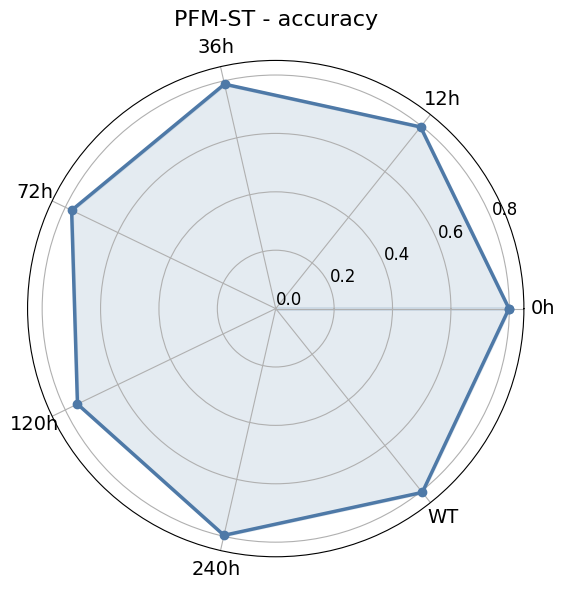

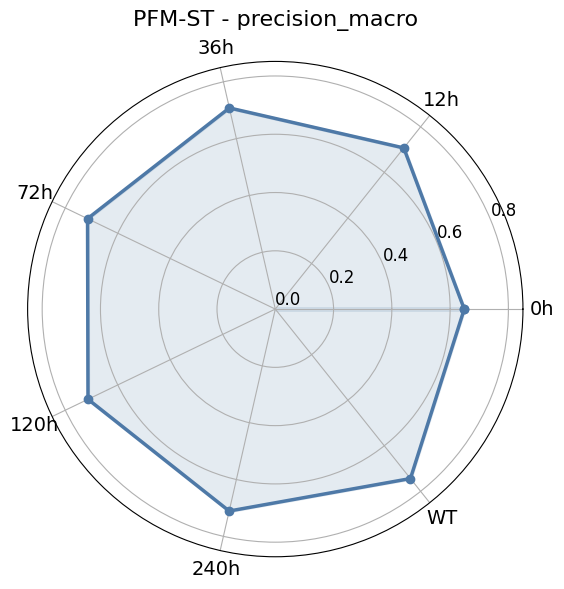

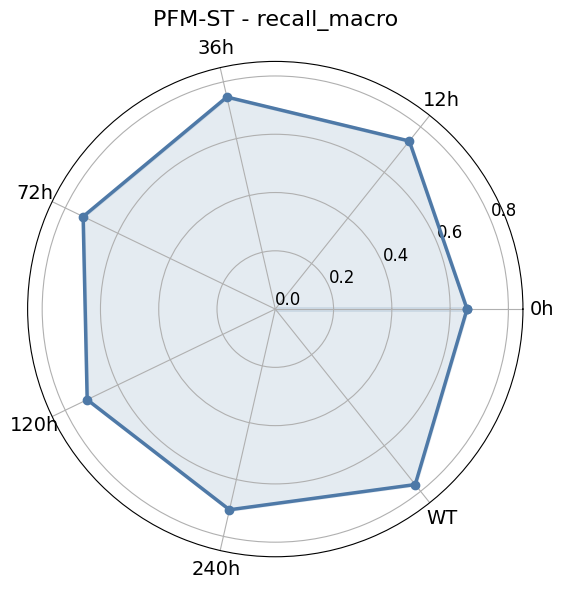

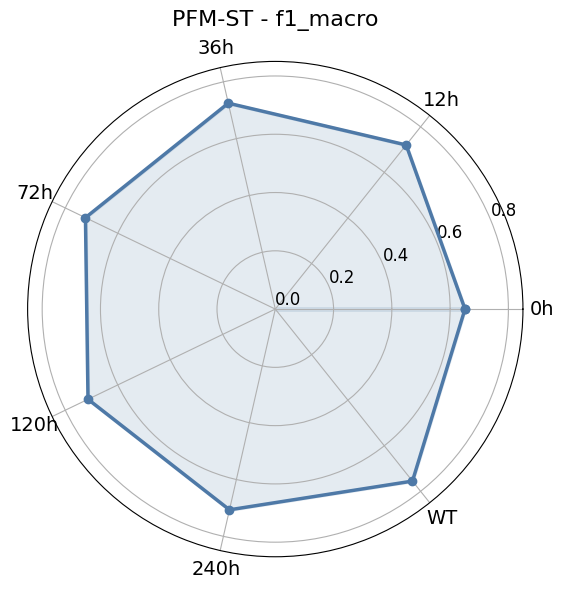

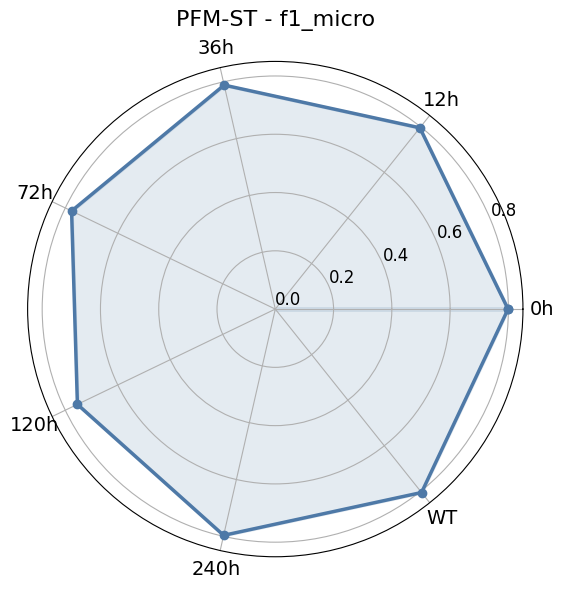

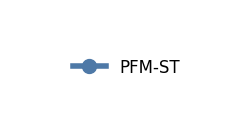

In [6]:
from pathlib import Path
from matplotlib.ticker import MaxNLocator
from IPython.display import display

# Result plotting utilities: single-model radar plots

def plot_results_radar(results, model_name='PFM-ST'):
    timepoints = ['0h', '12h', '1.5d', '3d', '5d', '10d', 'WT']
    stages = ['0h', '12h', '36h', '72h', '120h', '240h', 'WT']
    metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_micro']

    results_dict = {item['stage']: item for item in results}
    plot_color = '#4E79A7'

    for metric in metrics:
        num_points = len(timepoints)
        angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False).tolist()
        angles += angles[:1]

        values = [results_dict.get(tp, {}).get(metric, 0.0) for tp in timepoints]
        values += values[:1]

        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
        ax.plot(angles, values, marker='o', color=plot_color, linewidth=2.5)
        ax.fill_between(angles, values, alpha=0.15, color=plot_color, edgecolor=plot_color, linewidth=2.5)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(stages, fontsize=14)
        ax.set_ylim(0, 0.85)
        ax.tick_params(axis='y', labelsize=12)
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.set_title(f"{model_name} - {metric}", fontsize=16, va='bottom')
        plt.tight_layout()
        display(fig)
        plt.close(fig)

    legend_fig = plt.figure(figsize=(3, 1.5))
    legend = plt.Line2D([0], [0], color=plot_color, lw=4, marker='o', markersize=10, label=model_name)
    legend_ax = legend_fig.add_subplot(111)
    legend_ax.axis('off')
    legend_ax.legend(handles=[legend], loc='center', frameon=False, fontsize=12)
    display(legend_fig)
    plt.close(legend_fig)


if results:
    print('Currently only PFM-ST results available; plotting single-model radar charts.')
    plot_results_radar(results)


## Step 3: Compare Models on In-House Data

INFO:model_history:mapped model Geneformer -> /home/wwd/codebox/ODT-main/results/models/model_compare/Geneformer
INFO:model_history:mapped model PFM -> /home/wwd/codebox/ODT-main/results/models/model_compare/PFM
INFO:model_history:mapped model PFM-T -> /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-T
INFO:model_history:mapped model PFM-ST -> /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST
INFO:model_history:mapped model scFoundation -> /home/wwd/codebox/ODT-main/results/models/model_compare/scFoundation
INFO:model_history:mapped model scGPT -> /home/wwd/codebox/ODT-main/results/models/model_compare/scGPT
INFO:model_history:Reading history for: Geneformer
INFO:model_history:Reading history for: scGPT
INFO:model_history:Reading history for: scFoundation
INFO:model_history:Reading history for: PFM-ST


,model,timepoint,accuracy,accuracy_std,precision_macro,precision_macro_std,recall_macro,recall_macro_std,f1_macro,f1_macro_std,f1_micro,f1_micro_std
0,Geneformer,0h,0.576748,0.001202,0.274199,0.002998,0.284474,0.000406,0.266483,0.000671,0.576748,0.001202
1,Geneformer,12h,0.506998,0.001037,0.319347,0.063785,0.246223,0.000493,0.232356,0.000387,0.506998,0.001037
2,Geneformer,1.5d,0.614238,0.000452,0.292342,0.000965,0.318103,0.000592,0.301967,0.000688,0.614238,0.000452
3,Geneformer,3d,0.552888,0.000902,0.320755,0.029355,0.265247,0.001597,0.250948,0.001158,0.552888,0.000902
4,Geneformer,5d,0.452447,0.003550,0.332252,0.060701,0.232243,0.004680,0.196793,0.008511,0.452447,0.003550
5,Geneformer,10d,0.572739,0.002750,0.277583,0.004314,0.305268,0.003627,0.284803,0.004266,0.572739,0.002750
6,Geneformer,WT,0.606082,0.005415,0.535729,0.046964,0.409050,0.001895,0.404071,0.002174,0.606082,0.005415
7,scGPT,0h,0.601726,0.003429,0.274122,0.014218,0.323820,0.001702,0.291260,0.001406,0.601726,0.003429
8,scGPT,12h,0.494902,0.022841,0.301430,0.013037,0.274670,0.022502,0.266015,0.025482,0.494902,0.022841
9,scGPT,1.5d,0.577310,0.014665,0.311063,0.018766,0.295967,0.020213,0.283253,0.015356,0.577310,0.014665


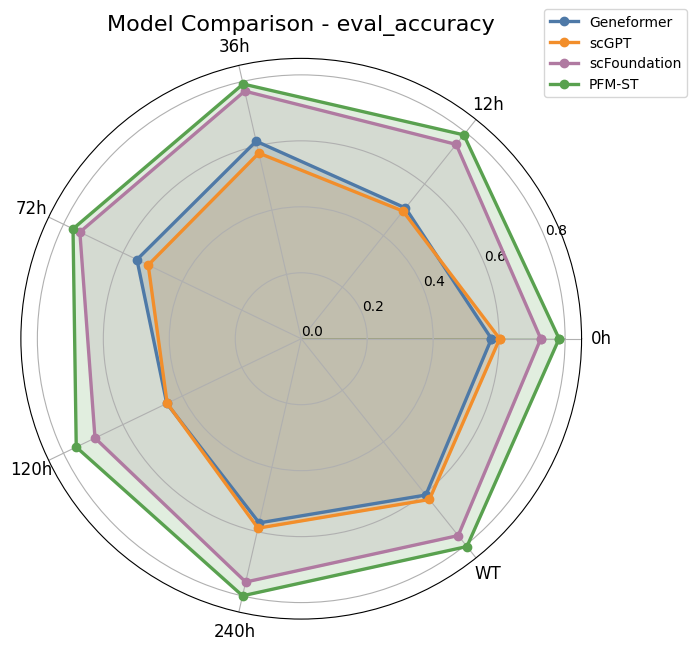

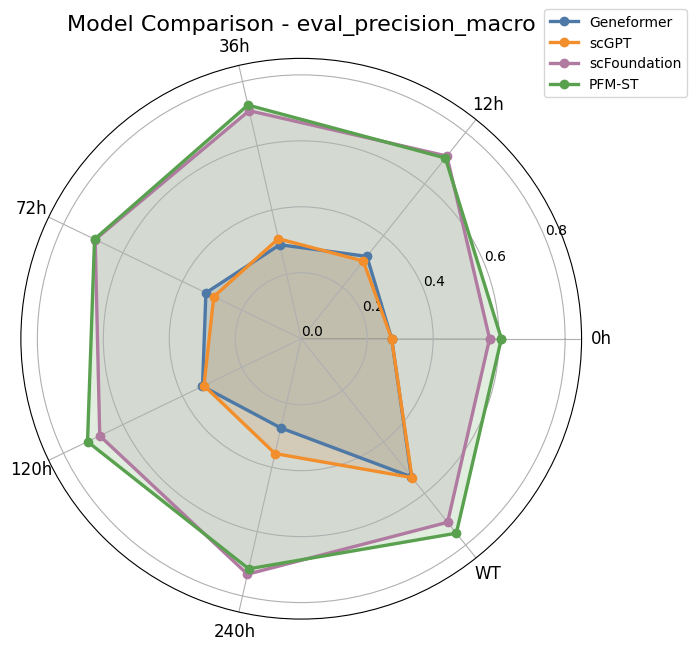

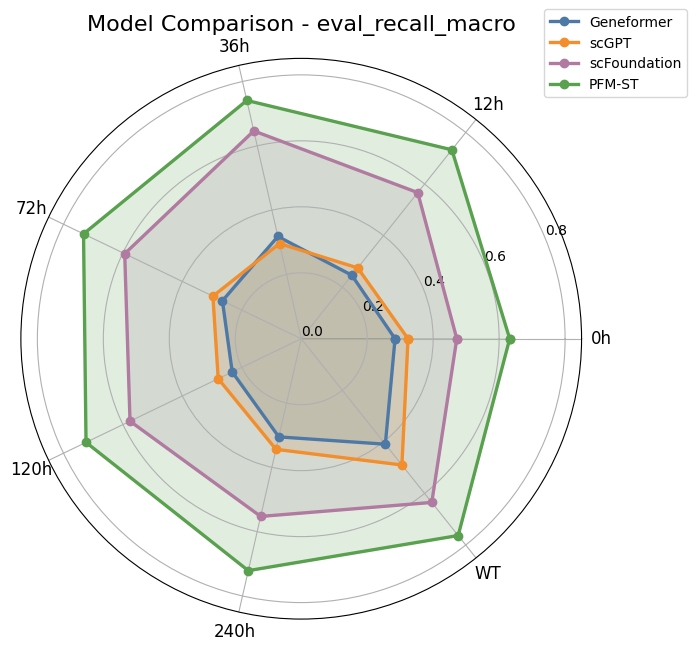

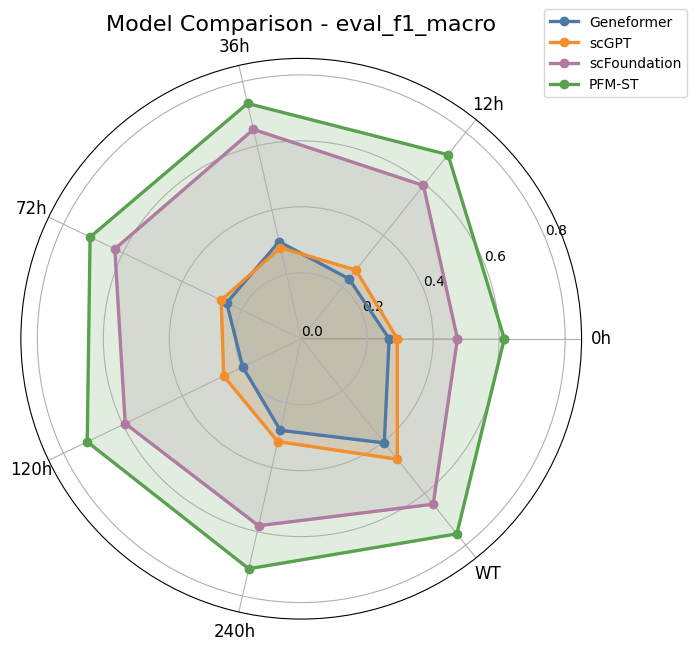

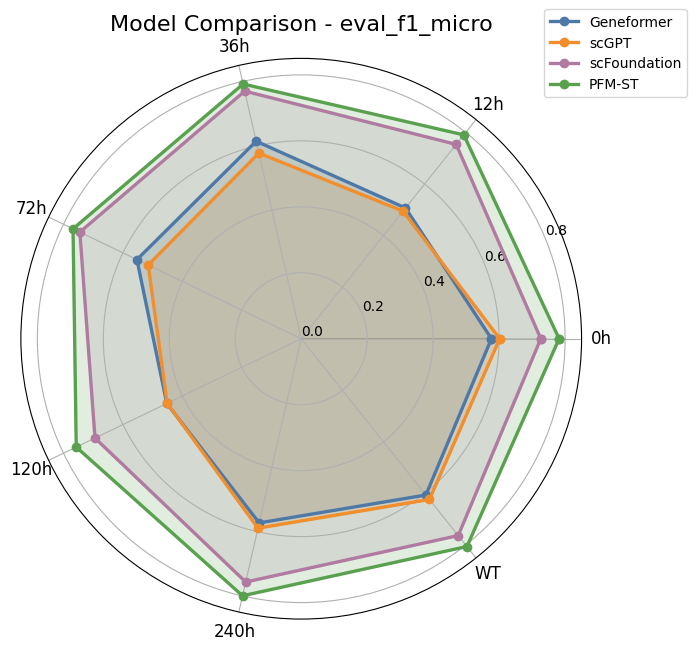

In [7]:
import json
import glob
import pickle
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from typing import Dict, List, Any, Optional
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('model_history')

# Production-grade model path management
BASE_COMPARE_DIR = Path(CODE_PATH) / 'results' / 'models' / 'model_compare'
DEFAULT_MODELS = ['Geneformer', 'PFM', 'PFM-T', 'PFM-ST', 'scFoundation', 'scGPT']

# Provide overrides for custom model paths if needed
def build_model_history_paths(base_dir: Path = BASE_COMPARE_DIR,
                              models: Optional[List[str]] = None,
                              overrides: Optional[Dict[str, str]] = None) -> Dict[str, Path]:
    models = models or DEFAULT_MODELS
    overrides = overrides or {}
    paths: Dict[str, Path] = {}
    for m in models:
        if m in overrides:
            p = Path(overrides[m])
        else:
            p = base_dir / m
        paths[m] = p
        logger.info('mapped model %s -> %s', m, str(p))
    return paths

# Default path mapping (can be overridden when calling)
model_history_path = build_model_history_paths()

TIMEPOINTS = ['0h', '12h', '1.5d', '3d', '5d', '10d', 'WT']


def safe_load_json(path: Path) -> Optional[Dict[str, Any]]:
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except Exception:
        return None


def getModelHistory(model_name: str, base_paths: Optional[Dict[str, Path]] = None) -> Dict[str, Dict[int, Dict[str, Any]]]:
    """Return nested dict: {timepoint: {rep_index: metrics_dict}}."""
    logger.info('Reading history for: %s', model_name)
    base_paths = base_paths or model_history_path
    model_history: Dict[str, Dict[int, Dict[str, Any]]] = {tp: {} for tp in TIMEPOINTS}
    base_path = base_paths.get(model_name)
    if base_path is None:
        logger.warning('No configured path for: %s', model_name)
        return model_history

    if model_name in {'Geneformer', 'PFM', 'PFM-T', 'PFM-ST'}:
        for tp in TIMEPOINTS:
            for rep in range(1, 4):
                rep_dir = Path(base_path) / tp / f'rep_{rep}'
                if not rep_dir.exists():
                    continue
                checkpoint_dirs = sorted(rep_dir.glob('checkpoint-*'), key=lambda p: int(p.name.split('-')[-1]) if p.name.split('-')[-1].isdigit() else 0)
                if not checkpoint_dirs:
                    continue
                ck = checkpoint_dirs[-1]
                trainer_state = safe_load_json(ck / 'trainer_state.json')
                final: Dict[str, Any] = {}
                if trainer_state and 'log_history' in trainer_state and trainer_state['log_history']:
                    final = dict(trainer_state['log_history'][-1])
                ts = safe_load_json(rep_dir / 'train_stats.json')
                if ts:
                    final.update(ts)
                if 'eval_accuracy' not in final and 'accuracy' in final:
                    final['eval_accuracy'] = final.get('accuracy')
                model_history[tp][rep] = final
    elif model_name == 'scFoundation':
        for tp in TIMEPOINTS:
            for rep in range(1, 4):
                rep_file = Path(base_path) / f"{tp}_rep_{rep}" / 'history.pkl'
                if not rep_file.exists():
                    continue
                try:
                    with open(rep_file, 'rb') as f:
                        history = pickle.load(f)
                except Exception:
                    continue
                result: Dict[str, Any] = {}
                train_time_sum = 0.0
                gpu_peak_max = 0.0
                metrics_names = {'accuracy', 'precision_macro', 'precision_micro', 'precision_weighted',
                                 'recall_macro', 'recall_micro', 'recall_weighted',
                                 'f1_macro', 'f1_micro', 'f1_weighted'}
                for epoch in history:
                    if 'train_time_sec' in epoch:
                        train_time_sum += epoch.get('train_time_sec', 0.0)
                    if 'gpu_peak_mem_mb' in epoch:
                        gpu_peak_max = max(gpu_peak_max, epoch.get('gpu_peak_mem_mb', 0.0))
                result['train_time_sec'] = train_time_sum
                result['gpu_peak_mem_mb'] = gpu_peak_max
                if len(history) > 0:
                    for k, v in history[-1].items():
                        if k in metrics_names:
                            result[f'eval_{k}'] = v
                        else:
                            if k not in {'train_time_sec', 'gpu_peak_mem_mb'}:
                                result[k] = v
                model_history[tp][rep] = result
    elif model_name == 'scGPT':
        for tp in TIMEPOINTS:
            for rep in range(1, 4):
                rep_file = Path(base_path) / f'time_dev_{tp}_2048_rep{rep}' / 'model_history.pkl'
                if not rep_file.exists():
                    continue
                try:
                    with open(rep_file, 'rb') as f:
                        history = pickle.load(f)
                except Exception:
                    continue
                model_history[tp][rep] = history[-1] if len(history) > 0 else {}
                summary_path = Path(base_path) / f'time_dev_{tp}_2048_rep{rep}' / 'summary.csv'
                if summary_path.exists():
                    try:
                        lines = summary_path.read_text().strip().splitlines()
                        if len(lines) >= 2:
                            keys = lines[0].split(',')
                            vals = lines[1].split(',')
                            d = dict(zip(keys, vals))
                            if 'train_time_sec' in d:
                                model_history[tp][rep]['train_time_sec'] = float(d['train_time_sec'])
                    except Exception:
                        pass
    else:
        logger.warning('Model type not covered: %s', model_name)

    return model_history


def get_all_model_mean(model_names: List[str], base_paths: Optional[Dict[str, Path]] = None) -> Dict[str, Dict[str, List[float]]]:
    base_paths = base_paths or model_history_path
    model_history_all: Dict[str, Dict[str, List[float]]] = {}
    for model in model_names:
        model_history_all[model] = {}
        history = getModelHistory(model, base_paths)
        for tp in TIMEPOINTS:
            reps = history.get(tp, {})
            accs, pms, rms, f1s, f1m = [], [], [], [], []
            for rep, data in reps.items():
                a = data.get('eval_accuracy', data.get('accuracy', None))
                pm = data.get('eval_precision_macro', data.get('precision_macro', None))
                rm = data.get('eval_recall_macro', data.get('recall_macro', None))
                f1 = data.get('eval_f1_macro', data.get('f1_macro', None))
                f1mi = data.get('eval_f1_micro', data.get('f1_micro', None))
                for lst, val in ((accs, a), (pms, pm), (rms, rm), (f1s, f1), (f1m, f1mi)):
                    if val is None:
                        continue
                    try:
                        lst.append(float(val))
                    except Exception:
                        pass
            def mean_std(lst: List[float]) -> List[float]:
                if not lst:
                    return [0.0, 0.0]
                return [float(np.mean(lst)), float(np.std(lst, ddof=1)) if len(lst) > 1 else 0.0]
            model_history_all[model][tp] = {
                'eval_accuracy': mean_std(accs),
                'eval_precision_macro': mean_std(pms),
                'eval_recall_macro': mean_std(rms),
                'eval_f1_macro': mean_std(f1s),
                'eval_f1_micro': mean_std(f1m)
            }
    return model_history_all


def radar_compare(model_history_all: Dict[str, Dict[str, List[float]]], model_names: List[str], title_suffix: str = 'compare') -> None:
    stages = ['0h', '12h', '36h', '72h', '120h', '240h', 'WT']
    metrics = ['eval_accuracy', 'eval_precision_macro', 'eval_recall_macro', 'eval_f1_macro', 'eval_f1_micro']
    palette = ['#4E79A7', '#F28E2B', '#B07AA1', '#59A14F', '#76B7B2', '#E15759']

    if not model_names:
        return

    for metric in metrics:
        angles = np.linspace(0, 2 * np.pi, len(TIMEPOINTS), endpoint=False).tolist()
        angles += angles[:1]
        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
        for idx, model in enumerate(model_names):
            values = [model_history_all.get(model, {}).get(tp, {}).get(metric, [0.0, 0.0])[0] for tp in TIMEPOINTS]
            values += values[:1]
            color = palette[idx % len(palette)]
            ax.plot(angles, values, marker='o', color=color, linewidth=2.4, label=model)
            ax.fill_between(angles, values, alpha=0.18, color=color)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(stages, fontsize=12)
        ax.set_ylim(0, 0.85)
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.set_title(f'Model Comparison - {metric}', fontsize=16, pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=10)
        plt.tight_layout()
        display(fig)
        plt.close(fig)


# Run model comparison and display radar charts
model_compare_list = ['Geneformer', 'scGPT', 'scFoundation', 'PFM-ST']
model_history_all = get_all_model_mean(model_compare_list)

# Show summary table of mean and std for comparison models
compare_summary = []
for model in model_compare_list:
    for tp in TIMEPOINTS:
        metrics = model_history_all.get(model, {}).get(tp, {})
        compare_summary.append({
            'model': model,
            'timepoint': tp,
            'accuracy': metrics.get('eval_accuracy', [0.0, 0.0])[0],
            'accuracy_std': metrics.get('eval_accuracy', [0.0, 0.0])[1],
            'precision_macro': metrics.get('eval_precision_macro', [0.0, 0.0])[0],
            'precision_macro_std': metrics.get('eval_precision_macro', [0.0, 0.0])[1],
            'recall_macro': metrics.get('eval_recall_macro', [0.0, 0.0])[0],
            'recall_macro_std': metrics.get('eval_recall_macro', [0.0, 0.0])[1],
            'f1_macro': metrics.get('eval_f1_macro', [0.0, 0.0])[0],
            'f1_macro_std': metrics.get('eval_f1_macro', [0.0, 0.0])[1],
            'f1_micro': metrics.get('eval_f1_micro', [0.0, 0.0])[0],
            'f1_micro_std': metrics.get('eval_f1_micro', [0.0, 0.0])[1],
        })
compare_summary_df = pd.DataFrame(compare_summary)
display(compare_summary_df)
compare_summary_df.to_csv(os.path.join(CODE_PATH, 'results','compare_summary.csv'), index=False)
radar_compare(model_history_all, model_compare_list)


INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM-T
INFO:model_history:Reading history for: PFM-ST
INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM-T
INFO:model_history:Reading history for: PFM-T
INFO:model_history:Reading history for: PFM-T
INFO:model_history:Reading history for: PFM-T
INFO:model_history:Reading history for: PFM-T
INFO:model_history:Reading history for: PFM-T
INFO:model_history:Reading history for: PFM-T


Ablation models: ['PFM', 'PFM-T', 'PFM-ST']
PFM rep counts: {'0h': 3, '12h': 3, '1.5d': 3, '3d': 3, '5d': 3, '10d': 3, 'WT': 3}
PFM-T rep counts: {'0h': 3, '12h': 3, '1.5d': 3, '3d': 3, '5d': 3, '10d': 3, 'WT': 3}
PFM-ST rep counts: {'0h': 3, '12h': 3, '1.5d': 3, '3d': 3, '5d': 3, '10d': 3, 'WT': 3}


,model,timepoint,accuracy,accuracy_std,precision_macro,precision_macro_std,recall_macro,recall_macro_std,f1_macro,f1_macro_std,f1_micro,f1_micro_std
0,PFM,0h,0.510445,0.003959,0.227381,0.002192,0.242978,0.003297,0.227902,0.002943,0.510445,0.003959
1,PFM,12h,0.474512,0.001305,0.220336,0.000566,0.227983,0.001131,0.212070,0.001364,0.474512,0.001305
2,PFM,1.5d,0.555391,0.001649,0.300683,0.031982,0.281057,0.000729,0.267575,0.001155,0.555391,0.001649
3,PFM,3d,0.548220,0.000521,0.312970,0.014559,0.269649,0.001375,0.252611,0.001265,0.548220,0.000521
4,PFM,5d,0.457474,0.002184,0.385791,0.021396,0.248652,0.001764,0.223678,0.002764,0.457474,0.002184
5,PFM,10d,0.533204,0.000592,0.255984,0.001617,0.274904,0.000549,0.256808,0.001215,0.533204,0.000592
6,PFM,WT,0.573445,0.004731,0.465654,0.013402,0.391287,0.004946,0.387696,0.007206,0.573445,0.004731
7,PFM-T,0h,0.674992,0.000694,0.412687,0.004459,0.371041,0.001053,0.362139,0.001507,0.674992,0.000694
8,PFM-T,12h,0.695870,0.000792,0.648086,0.005684,0.492932,0.007497,0.511133,0.009505,0.695870,0.000792
9,PFM-T,1.5d,0.710506,0.000342,0.648722,0.005879,0.516076,0.000982,0.534945,0.001791,0.710506,0.000342


INFO:model_history:Reading history for: PFM
INFO:model_history:Reading history for: PFM-T
INFO:model_history:Reading history for: PFM-ST


Plotting PFM family ablation radar charts...


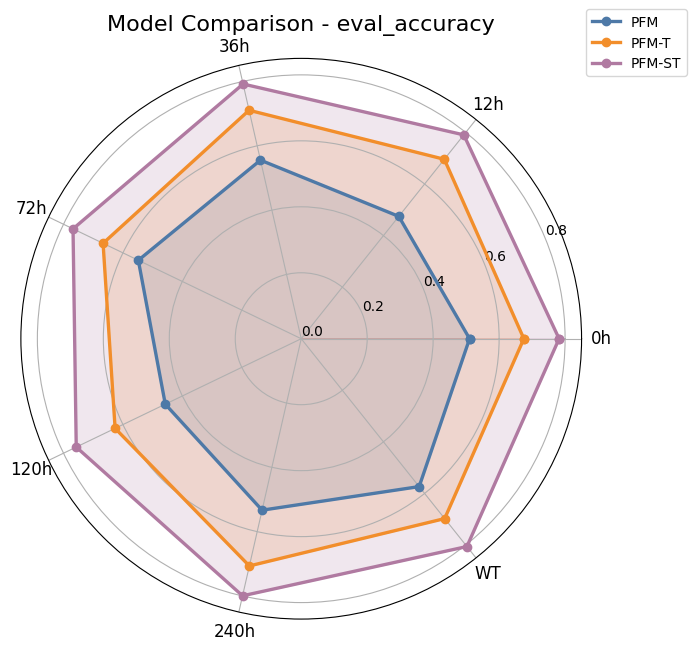

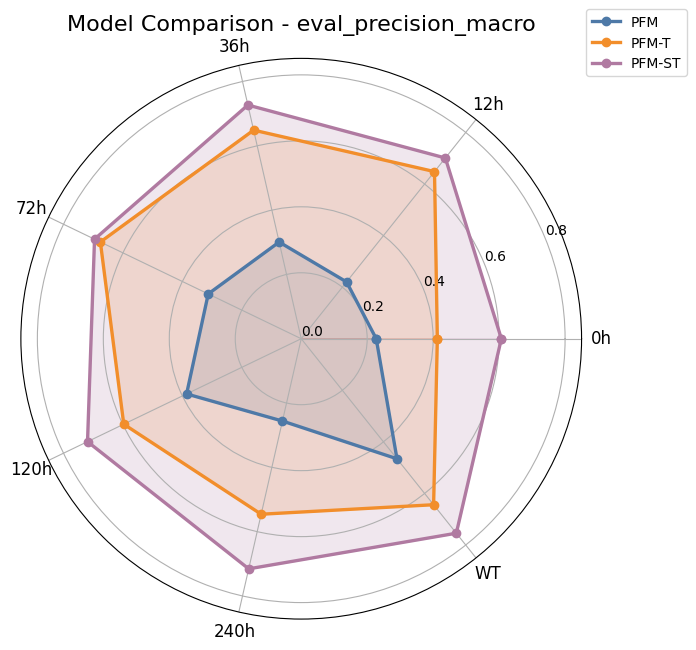

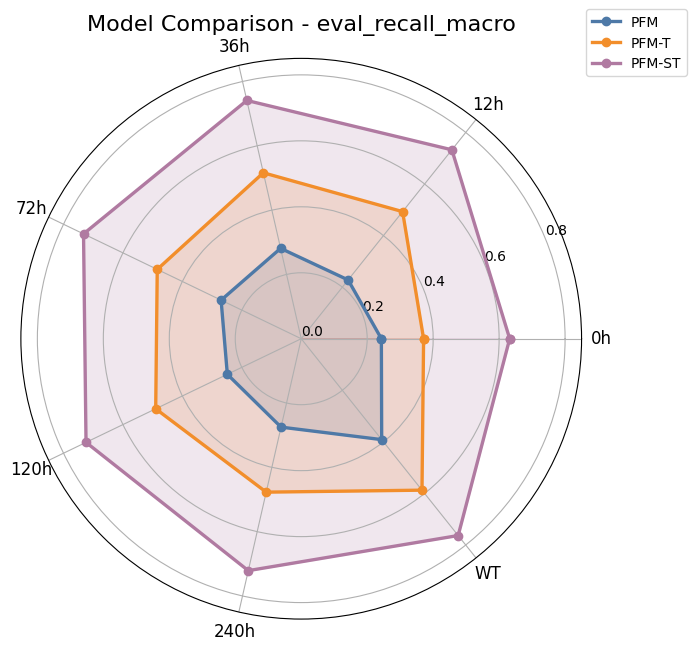

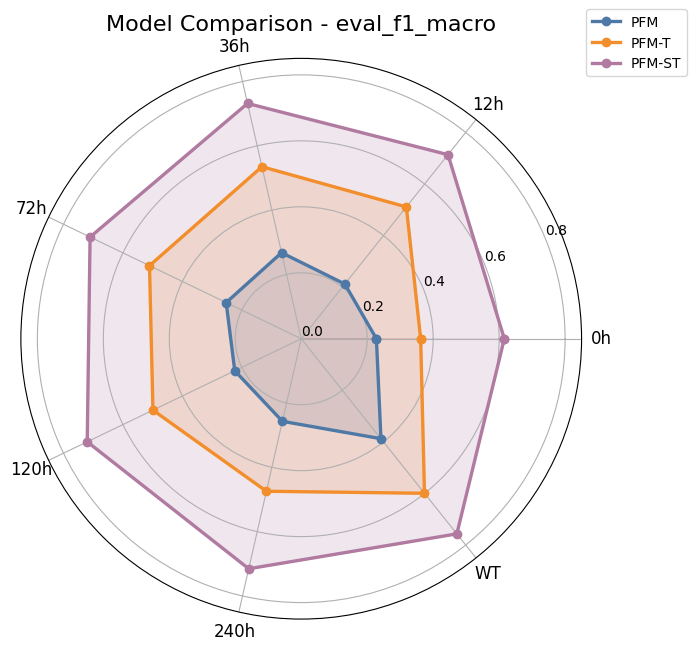

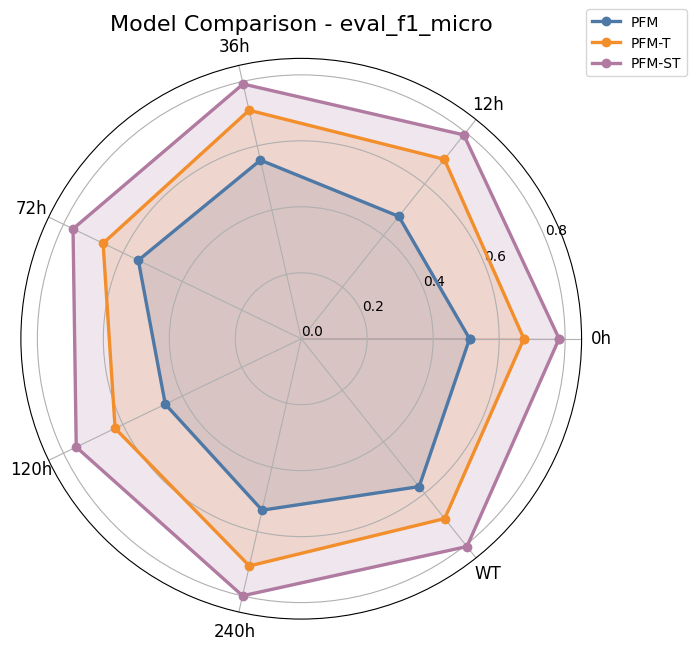

In [8]:
# Ablation study results for PFM / PFM-T / PFM-ST
ablation_models = ['PFM', 'PFM-T', 'PFM-ST']
print('Ablation models:', ablation_models)

raw_ablation_history = {m: getModelHistory(m, model_history_path) for m in ablation_models}
for model, history in raw_ablation_history.items():
    counts = {tp: len(history.get(tp, {})) for tp in TIMEPOINTS}
    print(f'{model} rep counts:', counts)

summary_records = []
for model in ablation_models:
    for tp in TIMEPOINTS:
        metrics = model_history_all.get(model, {}).get(tp, None)
        if metrics is None:
            metrics = get_all_model_mean([model], model_history_path)[model][tp]
        summary_records.append({
            'model': model,
            'timepoint': tp,
            'accuracy': metrics['eval_accuracy'][0],
            'accuracy_std': metrics['eval_accuracy'][1],
            'precision_macro': metrics['eval_precision_macro'][0],
            'precision_macro_std': metrics['eval_precision_macro'][1],
            'recall_macro': metrics['eval_recall_macro'][0],
            'recall_macro_std': metrics['eval_recall_macro'][1],
            'f1_macro': metrics['eval_f1_macro'][0],
            'f1_macro_std': metrics['eval_f1_macro'][1],
            'f1_micro': metrics['eval_f1_micro'][0],
            'f1_micro_std': metrics['eval_f1_micro'][1],
        })

summary_df = pd.DataFrame(summary_records)
display(summary_df)
summary_df.to_csv(os.path.join(CODE_PATH, 'results', 'ablation_summary.csv'), index=False)
print('Plotting PFM family ablation radar charts...')
model_history_ablation = get_all_model_mean(ablation_models, model_history_path)
radar_compare(model_history_ablation, ablation_models)


## Step 4: Compare Models on Public Data

In [9]:
# Paths to public dataset results for each model (under CODE_PATH/results/models/other_datasets)
import os

model_history_path_other_p = {
    'Geneformer': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'geneformer', 'geneformer_other_planarian'),
    'scGPT': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'scGPT', 'other_p'),
    'scFoundation': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'scFoundation','scf_time','planarian'),
    'PFM-ST': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'PFM-ST', 'ST_model_other_planarian'),
}

time_p = ['6h', '48h']

model_history_path_other_mouse = {
    'Geneformer': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'geneformer', 'geneformer_other_mouse'),
    'scGPT': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'scGPT', 'other_mouse'),
    'scFoundation': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'scFoundation','scf_time','mouse'),
    'PFM-ST': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'PFM-ST', 'ST_model_other_mouse'),
}

model_history_path_other_mouse_sub = {
    'Geneformer': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'geneformer', 'geneformer_other_mouse_sub'),
    'scGPT': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'scGPT', 'other_mouse_sub'),
    'scFoundation': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'scFoundation','scf_time','mouse'),
    'PFM-ST': os.path.join(CODE_PATH, 'results', 'models', 'other_datasets', 'PFM-ST', 'ST_model_other_mouse_sub'),
}

time_mouse = ['8months', '13months']


In [10]:
def get_model_history_other(model_save_dir,time_list,target=None):
    # This function reads public experimental results for comparison
    model_history_all = {}
    for model_name in model_save_dir:
        model_history_all[model_name] = {}
        if model_name in ['Geneformer','PFM-ST']:
            base_path = model_save_dir[model_name]
            for time in time_list:
                model_history_all[model_name][time] = {}
                for rep in range(1, 4):
                        rep_dir = f"{base_path}/{time}/rep_{rep}"
                        checkpoint_dirs = glob.glob(os.path.join(rep_dir, "checkpoint-*"))
                        if len(checkpoint_dirs) == 0:
                            print(f"no checkpoint found: {rep_dir}")
                            continue
                        checkpoint_dirs = sorted(
                            checkpoint_dirs,
                            key=lambda x: int(
                                os.path.basename(x).split("-")[-1]
                            )
                        )
                        checkpoint_dir = checkpoint_dirs[-1]
                        trainer_state_file = os.path.join(
                            checkpoint_dir,
                            "trainer_state.json"
                        )
                        if not os.path.exists(trainer_state_file):
                            print(f"missing {trainer_state_file}")
                            continue
                        with open(trainer_state_file, "r") as f:
                            trainer_state = json.load(f)
                        log_history = trainer_state["log_history"]
                        final = log_history[-1]
                        trainer_space_time_file = os.path.join(
                            rep_dir,
                            "train_stats.json"
                        )
                        with open(trainer_space_time_file, "r") as f:
                            trainer_stats = json.load(f)
                        for key in trainer_stats:
                            final[key] = trainer_stats[key]
                        model_history_all[model_name][time][rep] = final
        elif model_name in ['scFoundation']:

            base_path = model_save_dir[model_name]
            metrics = {
                'accuracy', 'precision_macro', 'precision_micro', 'precision_weighted',
                'recall_macro', 'recall_micro', 'recall_weighted',
                'f1_macro', 'f1_micro', 'f1_weighted'
            }
            for time in time_list:
                model_history_all[model_name][time] = {}
                for rep in ['seed42','seed43','seed44']:
                    if target is not None:
                        with open(f"{base_path}_{time}/{rep}/{target}/final_test_metrics.csv",'r')as file:
                            data = file.readlines()
                    else:
                        with open(f"{base_path}_{time}/{rep}/final_test_metrics.csv",'r')as file:
                            data = file.readlines()
                    data = [item.strip().split(',') for item in data]
                    model_result = dict(zip(data[0],data[1]))
                    result ={}
                    for k, v in model_result.items():
                        if k in metrics:
                            result[f"eval_{k}"] = v

                    model_history_all[model_name][time][rep] = result
       
        elif model_name in ['scGPT']:
            base_path = model_save_dir[model_name]
            for time in time_list:
                model_history_all[model_name][time]={}
                for rep in range(1, 4):
                    with open(f"{base_path}/time_dev_{time}_2048_rep{rep}/model_history.pkl",'rb')as file:
                        history = pickle.load(file)
                        model_history_all[model_name][time][rep]=history[-1]

    for model_name in model_history_all:
        for time in time_list:
            for rep in model_history_all[model_name][time]:
                print(f"{model_name}_time{time}_rep{rep}")
                print(model_history_all[model_name][time][rep])
    return model_history_all
    pass


In [11]:
print(model_history_path_other_p)

{'Geneformer': '/home/wwd/codebox/ODT-main/results/models/other_datasets/geneformer/geneformer_other_planarian', 'scGPT': '/home/wwd/codebox/ODT-main/results/models/other_datasets/scGPT/other_p', 'scFoundation': '/home/wwd/codebox/ODT-main/results/models/other_datasets/scFoundation/scf_time/planarian', 'PFM-ST': '/home/wwd/codebox/ODT-main/results/models/other_datasets/PFM-ST/ST_model_other_planarian'}


In [12]:
model_history_p = get_model_history_other(model_history_path_other_p,time_p)
model_history_mouse = get_model_history_other(model_history_path_other_mouse,time_mouse,target='cell')
model_history_mouse_sub = get_model_history_other(model_history_path_other_mouse_sub,time_mouse,target='sub')


Geneformer_time6h_rep1
{'epoch': 20.0, 'eval_accuracy': 0.6465962152863112, 'eval_f1_macro': 0.18568156877065642, 'eval_f1_micro': 0.6465962152863112, 'eval_f1_weighted': 0.5657877195398487, 'eval_loss': 1.0252974033355713, 'eval_precision_macro': 0.2908510416091936, 'eval_precision_micro': 0.6465962152863112, 'eval_precision_weighted': 0.5915083138797936, 'eval_recall_macro': 0.21213698116371582, 'eval_recall_micro': 0.6465962152863112, 'eval_recall_weighted': 0.6465962152863112, 'eval_runtime': 13.7532, 'eval_samples_per_second': 295.858, 'eval_steps_per_second': 24.721, 'step': 27100, 'rep': 1, 'train_time_sec': 1325.9651641845703, 'train_time_hour': 0.3683236567179362, 'gpu_peak_memory_MB': 5237.517578125, 'cpu_memory_before_MB': 2968.7265625, 'cpu_memory_after_MB': 2938.1875, 'train_size': 16249, 'test_size': 4069}
Geneformer_time6h_rep2
{'epoch': 20.0, 'eval_accuracy': 0.6419267633325141, 'eval_f1_macro': 0.1837071134198704, 'eval_f1_micro': 0.6419267633325141, 'eval_f1_weighted'

In [13]:
# Utility: convert a single model_history_all dict into per-rep DataFrame and aggregated summary, then display
import pandas as pd
import numpy as np
from IPython.display import display

def model_history_to_dfs(model_history_all: dict, dataset_label: str = None):
    """Convert a model_history_all dict -> (df_results, summary_df) and display both.

    model_history_all structure: { model_name: { time: { rep_key: {metric_name: value, ...}, ...}, ...}, ... }
    """
    records = []
    if not isinstance(model_history_all, dict):
        print('model_history_all must be a dict')
        return pd.DataFrame(), pd.DataFrame()

    for model_name, times in model_history_all.items():
        if not isinstance(times, dict):
            continue
        for time, reps in times.items():
            if not isinstance(reps, dict):
                continue
            for rep_key, metrics in reps.items():
                row = {
                    'dataset': dataset_label if dataset_label is not None else '',
                    'model': model_name,
                    'time': time,
                    'rep': rep_key,
                }
                if isinstance(metrics, dict):
                    for k, v in metrics.items():
                        # skip epoch attribute if present
                        if k == 'epoch':
                            continue
                        row[k] = v
                records.append(row)

    df_results = pd.DataFrame.from_records(records)
    # drop epoch column if still present for safety
    if 'epoch' in df_results.columns:
        df_results = df_results.drop(columns=['epoch'])

    # coerce eval_* to numeric
    for col in list(df_results.columns):
        if isinstance(col, str) and col.startswith('eval_'):
            df_results[col] = pd.to_numeric(df_results[col], errors='coerce')

    # remove any metric columns that contain NaN values (keep key columns)
    key_cols = ['dataset', 'model', 'time', 'rep']
    metric_cols = [c for c in df_results.columns if c not in key_cols]
    cols_with_nan = [c for c in metric_cols if df_results[c].isna().any()]
    if cols_with_nan:
        # drop them to satisfy requirement
        df_results = df_results.drop(columns=cols_with_nan)

    # aggregated summary
    agg_cols = {}
    if 'eval_accuracy' in df_results.columns:
        agg_cols['mean_accuracy'] = ('eval_accuracy', 'mean')
        agg_cols['std_accuracy'] = ('eval_accuracy', lambda x: x.std(ddof=1) if len(x)>1 else (0.0 if len(x)==1 else np.nan))
    # support both eval_f1_macro and eval_f1
    f1_col = 'eval_f1_macro' if 'eval_f1_macro' in df_results.columns else ('eval_f1' if 'eval_f1' in df_results.columns else None)
    if f1_col:
        agg_cols['mean_f1_macro'] = (f1_col, 'mean')
        agg_cols['std_f1_macro'] = (f1_col, lambda x: x.std(ddof=1) if len(x)>1 else (0.0 if len(x)==1 else np.nan))

    if agg_cols:
        summary_df = df_results.groupby(['dataset','model','time']).agg(**agg_cols).reset_index()
    else:
        summary_df = pd.DataFrame(columns=['dataset','model','time'])

    # Display
    print('\n-- Per-rep results --')
    display(df_results.sort_values(['dataset','model','time','rep']).reset_index(drop=True))
    print('\n-- Aggregated summary --')
    display(summary_df.sort_values(['dataset','model','time']).reset_index(drop=True))

    return df_results, summary_df

print('Updated utility function model_history_to_dfs (dropped epoch and NaN-containing columns)')


Updated utility function model_history_to_dfs (dropped epoch and NaN-containing columns)


In [14]:
def compare_heatmap(model_history_all, target='time_split'):
    """Plot a white->green heatmap for model_history_all without saving files.

    model_history_all: {model: {time: {rep: {metric: value}}} } or {model: {rep: {metric: value}}}
    target: 'time_split' to expand by timepoints, otherwise per-model aggregated rows
    """
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap

    metrics = [
        "eval_accuracy",
        "eval_f1_macro",
        "eval_precision_macro",
        "eval_recall_macro",
    ]
    metric_names = {
        "eval_accuracy": "Accuracy",
        "eval_f1_macro": "F1-Macro",
        "eval_precision_macro": "Precision-Macro",
        "eval_recall_macro": "Recall-Macro",
    }

    rows = []
    row_names = []
    model_names = list(model_history_all.keys())

    for model in model_names:
        if target == 'time_split':
            times_dict = model_history_all.get(model, {})
            for timepoint, reps in times_dict.items():
                agg = {}
                for rep, result in (reps or {}).items():
                    if not isinstance(result, dict):
                        continue
                    for m in metrics:
                        if m in result:
                            try:
                                v = float(result[m])
                            except Exception:
                                continue
                            agg.setdefault(m, []).append(v)
                mean_result = {k: float(np.mean(v)) for k, v in agg.items() if len(v) > 0}
                rows.append(mean_result)
                row_names.append(f"{model}-{timepoint}")
        else:
            reps = model_history_all.get(model, {})
            agg = {}
            for rep, result in (reps or {}).items():
                if not isinstance(result, dict):
                    continue
                for m in metrics:
                    if m in result:
                        try:
                            v = float(result[m])
                        except Exception:
                            continue
                        agg.setdefault(m, []).append(v)
            mean_result = {k: float(np.mean(v)) for k, v in agg.items() if len(v) > 0}
            rows.append(mean_result)
            row_names.append(f"{model}")

    df = pd.DataFrame(rows, index=row_names)
    # keep only columns present
    metrics_present = [m for m in metrics if m in df.columns]
    if not metrics_present:
        print('No supported metrics found in model_history_all')
        return df
    df = df[metrics_present]
    df.columns = [metric_names[m] for m in df.columns]

    # column-wise min-max normalization to [0,1]
    df_norm = df.copy()
    for col in df.columns:
        vmin, vmax = df[col].min(), df[col].max()
        if pd.isna(vmin) or pd.isna(vmax):
            df_norm[col] = np.nan
        elif vmax > vmin:
            df_norm[col] = (df[col] - vmin) / (vmax - vmin)
        else:
            df_norm[col] = 0.5

    # drop any metric column that contains NaN
    df = df.dropna(axis=1, how='any')
    df_norm = df_norm[df.columns]

    # plotting
    sns.set_theme(style="white", font_scale=1.0)
    plt.figure(
        figsize=(max(6, 1.2 * len(df.columns)), max(4, 0.4 * len(df))),
    )
    cmap = LinearSegmentedColormap.from_list(
        "white_green",
        ["#FFFFFF", "#E8F8EE", "#CFF0DA", "#9EE6C0", "#4EC56D", "#0B7A3A"],
        N=256,
    )
    ax = sns.heatmap(
        df_norm,
        cmap=cmap,
        annot=df.round(3),
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Normalized Performance", "ticks": []},
    )
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=25, ha="right")
    plt.yticks(rotation=0)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

print('Inserted compare_heatmap (inline, white->green)')


Inserted compare_heatmap (inline, white->green)



-- Per-rep results --


,dataset,model,time,rep,eval_accuracy,eval_f1_macro,eval_f1_micro,eval_f1_weighted,eval_precision_macro,eval_precision_micro,eval_precision_weighted,eval_recall_macro,eval_recall_micro,eval_recall_weighted
0,,Geneformer,48h,1,0.628396,0.252737,0.628396,0.553259,0.318406,0.628396,0.551169,0.278861,0.628396,0.628396
1,,Geneformer,48h,2,0.633948,0.256945,0.633948,0.558824,0.295850,0.633948,0.543334,0.293156,0.633948,0.633948
2,,Geneformer,48h,3,0.633551,0.253277,0.633551,0.557594,0.280054,0.633551,0.534234,0.288866,0.633551,0.633551
3,,Geneformer,6h,1,0.646596,0.185682,0.646596,0.565788,0.290851,0.646596,0.591508,0.212137,0.646596,0.646596
4,,Geneformer,6h,2,0.641927,0.183707,0.641927,0.561558,0.164684,0.641927,0.503932,0.210289,0.641927,0.641927
5,,Geneformer,6h,3,0.645859,0.184745,0.645859,0.564721,0.165442,0.645859,0.506223,0.211571,0.645859,0.645859
6,,PFM-ST,48h,1,0.714059,0.603509,0.714059,0.722143,0.570562,0.714059,0.743725,0.653104,0.714059,0.714059
7,,PFM-ST,48h,2,0.726750,0.603176,0.726750,0.730986,0.601298,0.726750,0.743722,0.622252,0.726750,0.726750
8,,PFM-ST,48h,3,0.734087,0.603820,0.734087,0.731978,0.596162,0.734087,0.733911,0.618755,0.734087,0.734087
9,,PFM-ST,6h,1,0.753502,0.519923,0.753502,0.759360,0.504099,0.753502,0.769315,0.546975,0.753502,0.753502



-- Aggregated summary --


,dataset,model,time,mean_accuracy,std_accuracy,mean_f1_macro,std_f1_macro
0,,Geneformer,48h,0.631965,0.003097,0.254320,0.002290
1,,Geneformer,6h,0.644794,0.002510,0.184711,0.000988
2,,PFM-ST,48h,0.724965,0.010132,0.603502,0.000322
3,,PFM-ST,6h,0.757680,0.008769,0.525106,0.005474
4,,scFoundation,48h,0.727411,0.007734,0.423124,0.037589
5,,scFoundation,6h,0.745474,0.008479,0.416984,0.018320
6,,scGPT,48h,0.697336,0.007515,0.383384,0.011033
7,,scGPT,6h,0.716884,0.007725,0.350995,0.018143


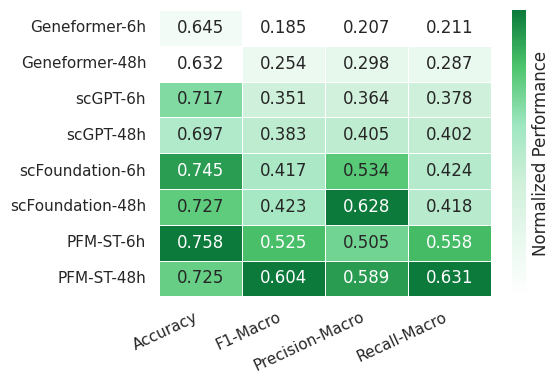

In [15]:
model_history_to_dfs(model_history_p)
compare_heatmap(model_history_p)


-- Per-rep results --


,dataset,model,time,rep,eval_accuracy,eval_f1_macro,eval_f1_micro,eval_f1_weighted,eval_precision_macro,eval_precision_micro,eval_precision_weighted,eval_recall_macro,eval_recall_micro,eval_recall_weighted
0,,Geneformer,13months,1,0.538102,0.278849,0.538102,0.475033,0.330056,0.538102,0.478005,0.305011,0.538102,0.538102
1,,Geneformer,13months,2,0.565728,0.298400,0.565728,0.499870,0.324455,0.565728,0.482327,0.322533,0.565728,0.565728
2,,Geneformer,13months,3,0.566395,0.298067,0.566395,0.500844,0.319361,0.566395,0.480514,0.322771,0.566395,0.566395
3,,Geneformer,8months,1,0.533573,0.237381,0.533573,0.450914,0.368194,0.533573,0.499136,0.264410,0.533573,0.533573
4,,Geneformer,8months,2,0.503890,0.196917,0.503890,0.402687,0.226156,0.503890,0.403763,0.232931,0.503890,0.503890
5,,Geneformer,8months,3,0.506628,0.200468,0.506628,0.407722,0.308509,0.506628,0.457338,0.235725,0.506628,0.506628
6,,PFM-ST,13months,1,0.845456,0.762643,0.845456,0.845923,0.762167,0.845456,0.846959,0.764115,0.845456,0.845456
7,,PFM-ST,13months,2,0.832644,0.747524,0.832644,0.831293,0.767677,0.832644,0.832990,0.737220,0.832644,0.832644
8,,PFM-ST,13months,3,0.837181,0.753765,0.837181,0.836992,0.755367,0.837181,0.838716,0.755594,0.837181,0.837181
9,,PFM-ST,8months,1,0.831844,0.692734,0.831844,0.828484,0.713950,0.831844,0.830867,0.686041,0.831844,0.831844



-- Aggregated summary --


,dataset,model,time,mean_accuracy,std_accuracy,mean_f1_macro,std_f1_macro
0,,Geneformer,13months,0.556742,0.016146,0.291772,0.011193
1,,Geneformer,8months,0.514697,0.016404,0.211588,0.022407
2,,PFM-ST,13months,0.838427,0.006496,0.754644,0.007598
3,,PFM-ST,8months,0.825696,0.005480,0.681553,0.012579
4,,scFoundation,13months,0.797277,0.013079,0.659998,0.011509
5,,scFoundation,8months,0.781268,0.016233,0.631588,0.022852
6,,scGPT,13months,0.684061,0.024253,0.479932,0.027008
7,,scGPT,8months,0.634774,0.020416,0.428215,0.015687


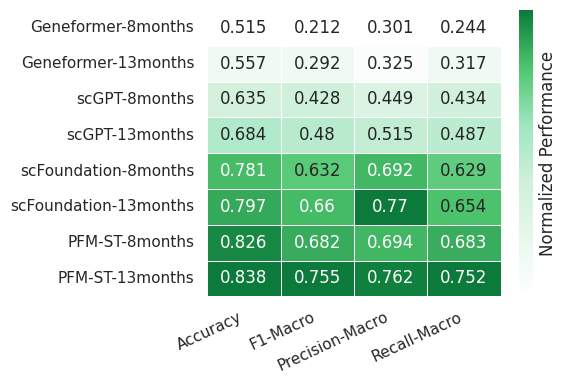

In [16]:
model_history_to_dfs(model_history_mouse)
compare_heatmap(model_history_mouse)


-- Per-rep results --


,dataset,model,time,rep,eval_accuracy,eval_f1_macro,eval_f1_micro,eval_f1_weighted,eval_precision_macro,eval_precision_micro,eval_precision_weighted,eval_recall_macro,eval_recall_micro,eval_recall_weighted
0,,Geneformer,13months,1,0.428667,0.116573,0.428667,0.350801,0.126123,0.428667,0.325470,0.140603,0.428667,0.428667
1,,Geneformer,13months,2,0.413986,0.112386,0.413986,0.341956,0.125091,0.413986,0.315613,0.137230,0.413986,0.413986
2,,Geneformer,13months,3,0.409449,0.110293,0.409449,0.335964,0.123693,0.409449,0.310034,0.135348,0.409449,0.409449
3,,Geneformer,8months,1,0.365130,0.093442,0.365130,0.283446,0.099593,0.365130,0.273373,0.122354,0.365130,0.365130
4,,Geneformer,8months,2,0.373775,0.096614,0.373775,0.288975,0.118878,0.373775,0.306042,0.127632,0.373775,0.373775
5,,Geneformer,8months,3,0.372767,0.096403,0.372767,0.288315,0.089786,0.372767,0.256285,0.127495,0.372767,0.372767
6,,PFM-ST,13months,1,0.670359,0.497291,0.670359,0.653030,0.534853,0.670359,0.660496,0.505079,0.670359,0.670359
7,,PFM-ST,13months,2,0.694248,0.566449,0.694248,0.690679,0.574844,0.694248,0.698255,0.577062,0.694248,0.694248
8,,PFM-ST,13months,3,0.666489,0.519503,0.666489,0.664548,0.532454,0.666489,0.676301,0.534524,0.666489,0.666489
9,,PFM-ST,8months,1,0.673487,0.529395,0.673487,0.665470,0.530277,0.673487,0.668141,0.545562,0.673487,0.673487



-- Aggregated summary --


,dataset,model,time,mean_accuracy,std_accuracy,mean_f1_macro,std_f1_macro
0,,Geneformer,13months,0.417367,0.010045,0.113084,0.003198
1,,Geneformer,8months,0.370557,0.004727,0.095487,0.001774
2,,PFM-ST,13months,0.677032,0.015035,0.527748,0.035308
3,,PFM-ST,8months,0.647358,0.023122,0.489639,0.035210
4,,scFoundation,13months,0.608123,0.018125,0.333492,0.020946
5,,scFoundation,8months,0.574736,0.017704,0.302148,0.024066
6,,scGPT,13months,0.467636,0.013841,0.178880,0.011490
7,,scGPT,8months,0.431220,0.022490,0.149258,0.008565


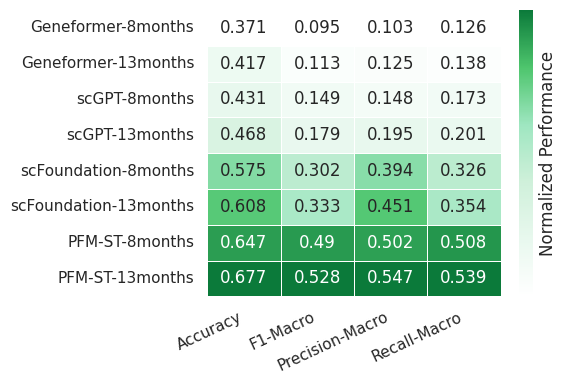

In [17]:
model_history_to_dfs(model_history_mouse_sub)
compare_heatmap(model_history_mouse_sub)